P.S. ROC AUC получился низким. Технически модели правильно обучены, просто признак Turbo в этом наборе с низкой показательной способностью. (в регрессии бустинг показал нормальный результат)

In [ ]:
!pip install shap catboost

Применяется SMOTE для балансировки обучающей выборки
обучение AdaBoost...
Лучшие параметры AdaBoost: {'learning_rate': 1.0, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.14      0.49      0.22       583
           1       0.85      0.50      0.63      3417

    accuracy                           0.50      4000
   macro avg       0.50      0.49      0.42      4000
weighted avg       0.75      0.50      0.57      4000

обучение GradientBoosting...
Лучшие параметры GradientBoosting: {'max_depth': 4, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.14      0.31      0.19       583
           1       0.85      0.67      0.75      3417

    accuracy                           0.62      4000
   macro avg       0.50      0.49      0.47      4000
weighted avg       0.75      0.62      0.67      4000

обучение XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:23:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Лучшие параметры XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.14      0.34      0.20       583
           1       0.85      0.63      0.73      3417

    accuracy                           0.59      4000
   macro avg       0.49      0.49      0.46      4000
weighted avg       0.75      0.59      0.65      4000

обучение CatBoost...
Лучшие параметры CatBoost: {'depth': 6, 'iterations': 100}
              precision    recall  f1-score   support

           0       0.15      0.37      0.22       583
           1       0.86      0.65      0.74      3417

    accuracy                           0.61      4000
   macro avg       0.51      0.51      0.48      4000
weighted avg       0.76      0.61      0.67      4000



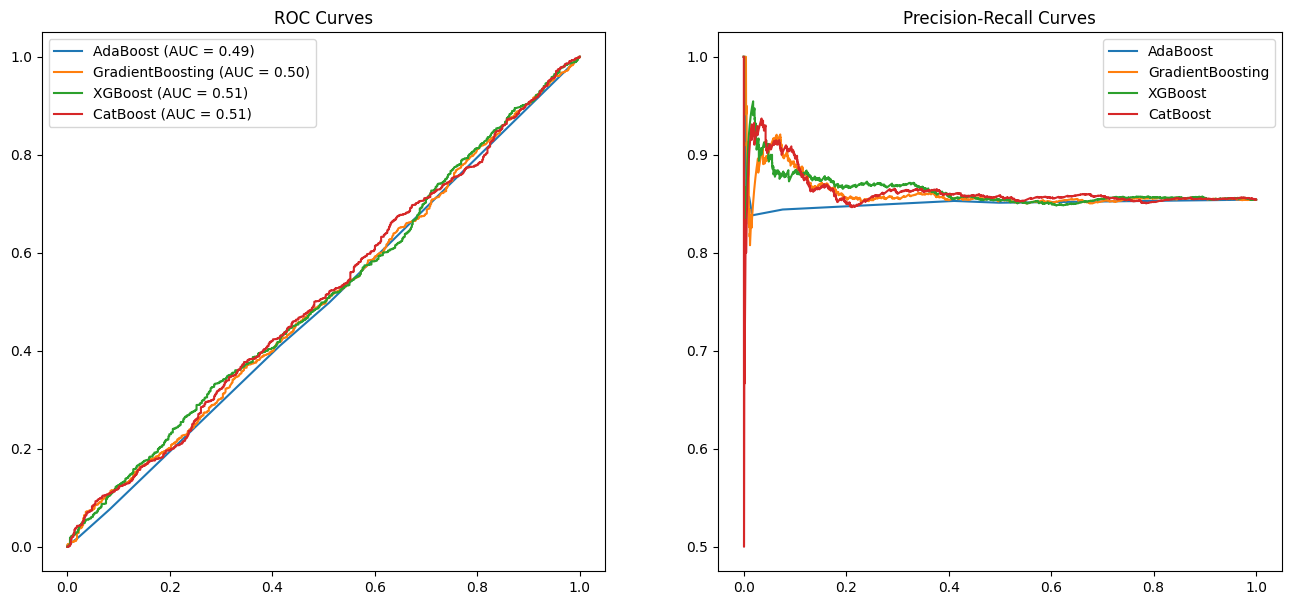


Анализ SHAP для лучшей модели...
Force plot (объект №0):


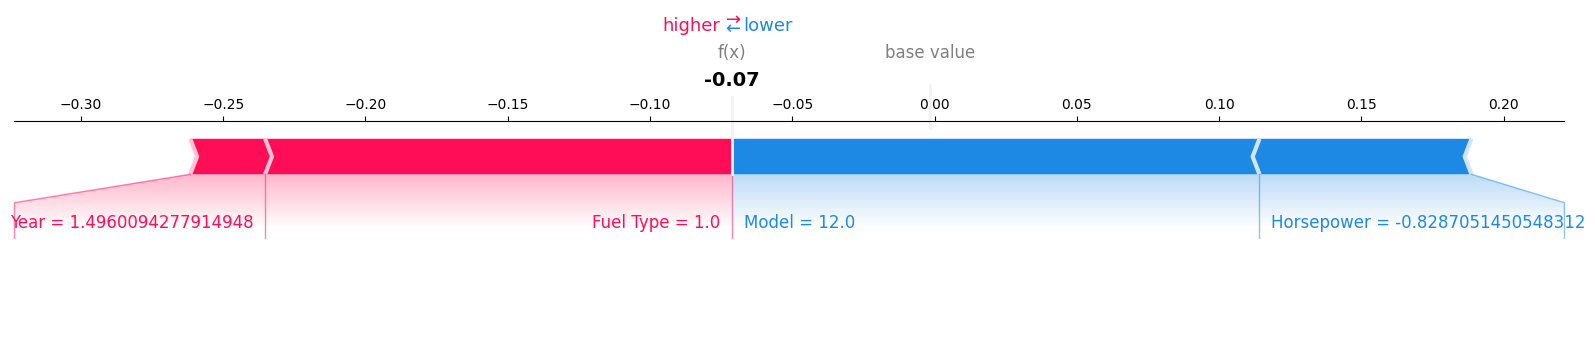

Bar plot (объект №0):


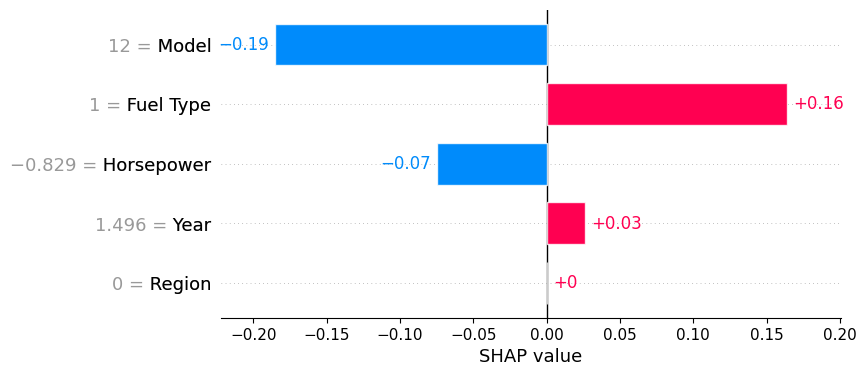

Waterfall plot (объект №0):


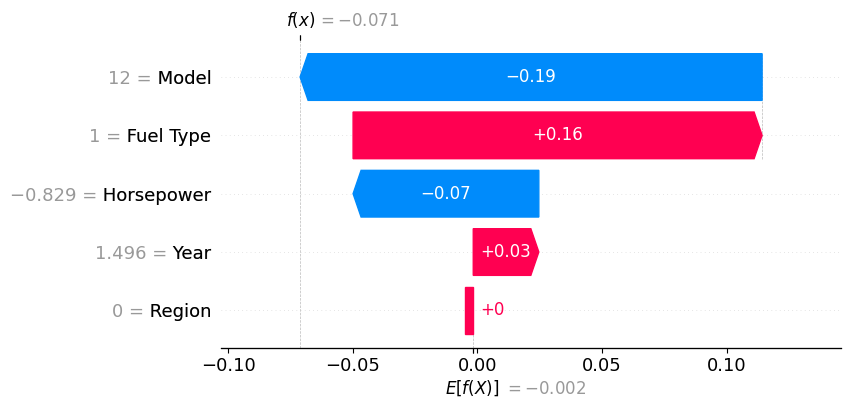

Scatter plot (относительно себя):


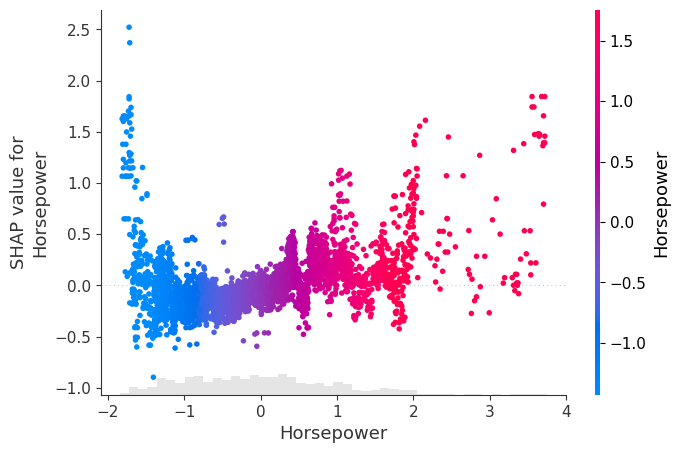

Scatter plot (относительно Model):


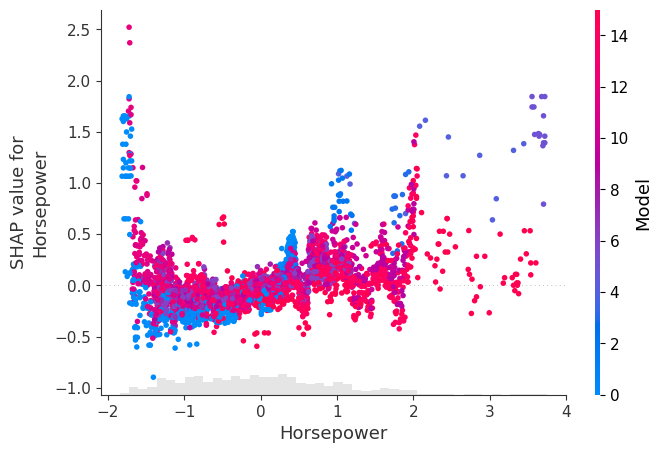

Beeswarm plot (общая важность):


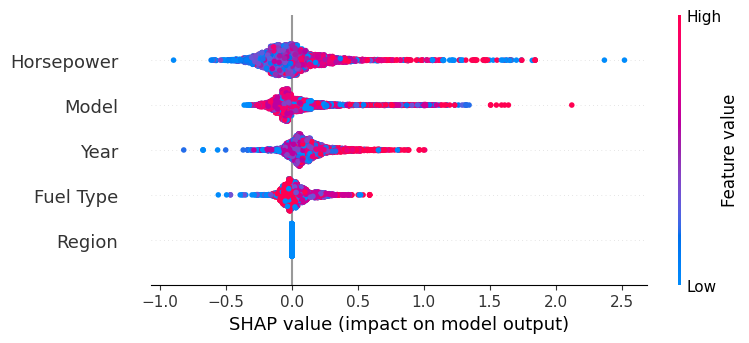

Bar plot (общая важность):


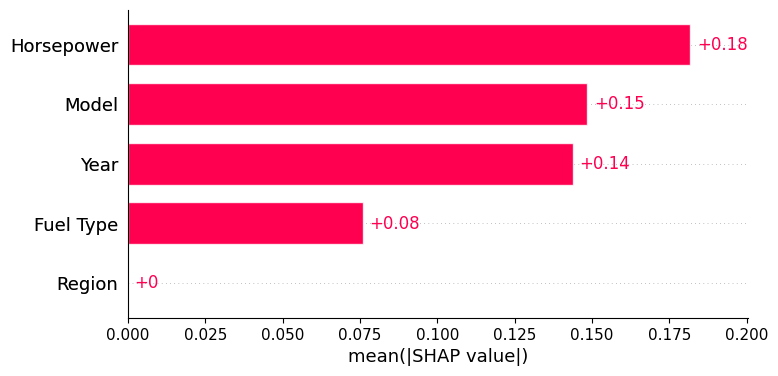

Фильтрация: выбраны топ-3 признака ['Horsepower', 'Model', 'Year']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:24:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Метрики после фильтрации признаков:
              precision    recall  f1-score   support

           0       0.14      0.36      0.20       583
           1       0.85      0.61      0.71      3417

    accuracy                           0.57      4000
   macro avg       0.49      0.48      0.45      4000
weighted avg       0.74      0.57      0.63      4000


Регрессия (Base Price) ---
R2 до фильтрации: 0.7692
Фильтрация регрессии: выбраны ['Year', 'Horsepower', 'Model']
R2 после фильтрации: 0.7669
MAE: 23748.96


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, roc_curve, auc,
                             precision_recall_curve, mean_squared_error,
                             mean_absolute_error, r2_score)

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from imblearn.over_sampling import SMOTE

# 1. считывание данных
df_full = pd.read_csv('/content/drive/MyDrive/Учёба/8 семестр/ТИИ/mercedes_benz_sales_2020_2025.csv')
df = df_full.sample(n=20000, random_state=42).copy()

# 2. подготовка данных
# предобработка
df = df.drop(['Color', 'Sales Volume'], axis=1).dropna()

# кодирование категориальных признаков (Label Encoding)
le = LabelEncoder()
cat_features = ['Model', 'Region', 'Fuel Type', 'Turbo']
for col in cat_features:
    df[col] = le.fit_transform(df[col])

# нормализация численных данных
scaler = StandardScaler()
num_cols = ['Horsepower', 'Year']
df[num_cols] = scaler.fit_transform(df[num_cols])

# разбиение для классификации
x = df.drop(['Turbo', 'Base Price (USD)'], axis=1)
y = df['Turbo']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# снижение дисбаланса классов (SMOTE)
print("Применяется SMOTE для балансировки обучающей выборки")
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# 3. классификаторы: подбор гиперпараметров и метрики
models = {
    'AdaBoost': (AdaBoostClassifier(random_state=42),
                 {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}),
    'GradientBoosting': (GradientBoostingClassifier(random_state=42),
                         {'n_estimators': [50, 100], 'max_depth': [3, 4]}),
    'XGBoost': (XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                {'n_estimators': [50, 100], 'learning_rate': [0.1], 'max_depth': [3, 5]}),
    'CatBoost': (CatBoostClassifier(silent=True),
                 {'iterations': [50, 100], 'depth': [4, 6]})
}

best_clf = None
max_auc = 0

plt.figure(figsize=(16, 7))
ax_roc = plt.subplot(1, 2, 1)
ax_pr = plt.subplot(1, 2, 2)

for name, (model, params) in models.items():
    print(f"обучение {name}...")
    grid = GridSearchCV(model, params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(x_train_res, y_train_res)
    m = grid.best_estimator_

    y_prob = m.predict_proba(x_test)[:, 1]

    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # PR-Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax_pr.plot(recall, precision, label=name)

    print(f"Лучшие параметры {name}: {grid.best_params_}")
    print(classification_report(y_test, m.predict(x_test)))

    if roc_auc > max_auc:
        max_auc = roc_auc
        best_clf = m

ax_roc.set_title('ROC Curves')
ax_roc.legend()
ax_pr.set_title('Precision-Recall Curves')
ax_pr.legend()
plt.show()

# 4. важность признаков (SHAP)
print("\nАнализ SHAP для лучшей модели...")
explainer = shap.TreeExplainer(best_clf)
# используем небольшую выборку из теста для ускорения графиков force_plot
shap_values = explainer(x_test)

# Force plot (один объект)
print("Force plot (объект №0):")
shap.plots.force(shap_values[0], matplotlib=True)

# Bar plot (один объект)
print("Bar plot (объект №0):")
shap.plots.bar(shap_values[0])

# Waterfall plot (один объект)
print("Waterfall plot (объект №0):")
shap.plots.waterfall(shap_values[0])

# Scatter plots
print("Scatter plot (относительно себя):")
shap.plots.scatter(shap_values[:, "Horsepower"], color=shap_values[:, "Horsepower"])
print("Scatter plot (относительно Model):")
shap.plots.scatter(shap_values[:, "Horsepower"], color=shap_values[:, "Model"])

# Beeswarm plot (все признаки)
print("Beeswarm plot (общая важность):")
shap.plots.beeswarm(shap_values)

# Bar plot (все признаки)
print("Bar plot (общая важность):")
shap.plots.bar(shap_values)

# фильтрация на основе важности (оставим 3 самых важных)
vals = np.abs(shap_values.values).mean(0)
feature_importance = pd.DataFrame(list(zip(x.columns, vals)), columns=['col','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)
top_3_features = feature_importance['col'].head(3).tolist()

print(f"Фильтрация: выбраны топ-3 признака {top_3_features}")
x_train_f = x_train_res[top_3_features]
x_test_f = x_test[top_3_features]

best_clf.fit(x_train_f, y_train_res)
print("\nМетрики после фильтрации признаков:")
print(classification_report(y_test, best_clf.predict(x_test_f)))

# визуализация дерева (для GradientBoosting или XGBoost)
if hasattr(best_clf, 'estimators_'): # для GradientBoosting
    from sklearn import tree
    plt.figure(figsize=(20,10))
    tree.plot_tree(best_clf.estimators_[0, 0], feature_names=top_3_features, filled=True, max_depth=2)
    plt.title("визуализация одного дерева из ансамбля")
    plt.show()

# 5. регрессия (CatBoostRegressor)
print("\nРегрессия (Base Price) ---")
xr = df.drop(['Base Price (USD)'], axis=1)
yr = df['Base Price (USD)']
xr_train, xr_test, yr_train, yr_test = train_test_split(xr, yr, test_size=0.2, random_state=42)

reg_params = {'iterations': [100], 'depth': [5], 'learning_rate': [0.1]}
reg_grid = GridSearchCV(CatBoostRegressor(silent=True), reg_params, cv=3)
reg_grid.fit(xr_train, yr_train)

# метрики до фильтрации
yr_pred = reg_grid.best_estimator_.predict(xr_test)
print(f"R2 до фильтрации: {r2_score(yr_test, yr_pred):.4f}")

# фильтрация для регрессии (аналогично через важность)
importances_reg = reg_grid.best_estimator_.feature_importances_
top_reg_features = xr.columns[np.argsort(importances_reg)[-3:]].tolist()
print(f"Фильтрация регрессии: выбраны {top_reg_features}")

# переобучение регрессии
reg_grid.best_estimator_.fit(xr_train[top_reg_features], yr_train)
yr_pred_f = reg_grid.best_estimator_.predict(xr_test[top_reg_features])
print(f"R2 после фильтрации: {r2_score(yr_test, yr_pred_f):.4f}")
print(f"MAE: {mean_absolute_error(yr_test, yr_pred_f):.2f}")